In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("superstore.csv", encoding='latin1')

df.head()

C:\Users\dasra\AppData\Local\Temp\ipykernel_5884\2158234798.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("superstore.csv", encoding='latin1')


,Row ID,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,...,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit,Order
0,1,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,No,261.9600,2,0.00,41.9136,08/11/2016
1,2,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",No,731.9400,3,0.00,219.5820,08/11/2016
2,3,CA-2016-138688,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,No,14.6200,2,0.00,6.8714,12/06/2016
3,4,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,No,957.5775,5,0.45,-383.0310,11/10/2015
4,5,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,No,22.3680,2,0.20,2.5164,11/10/2015


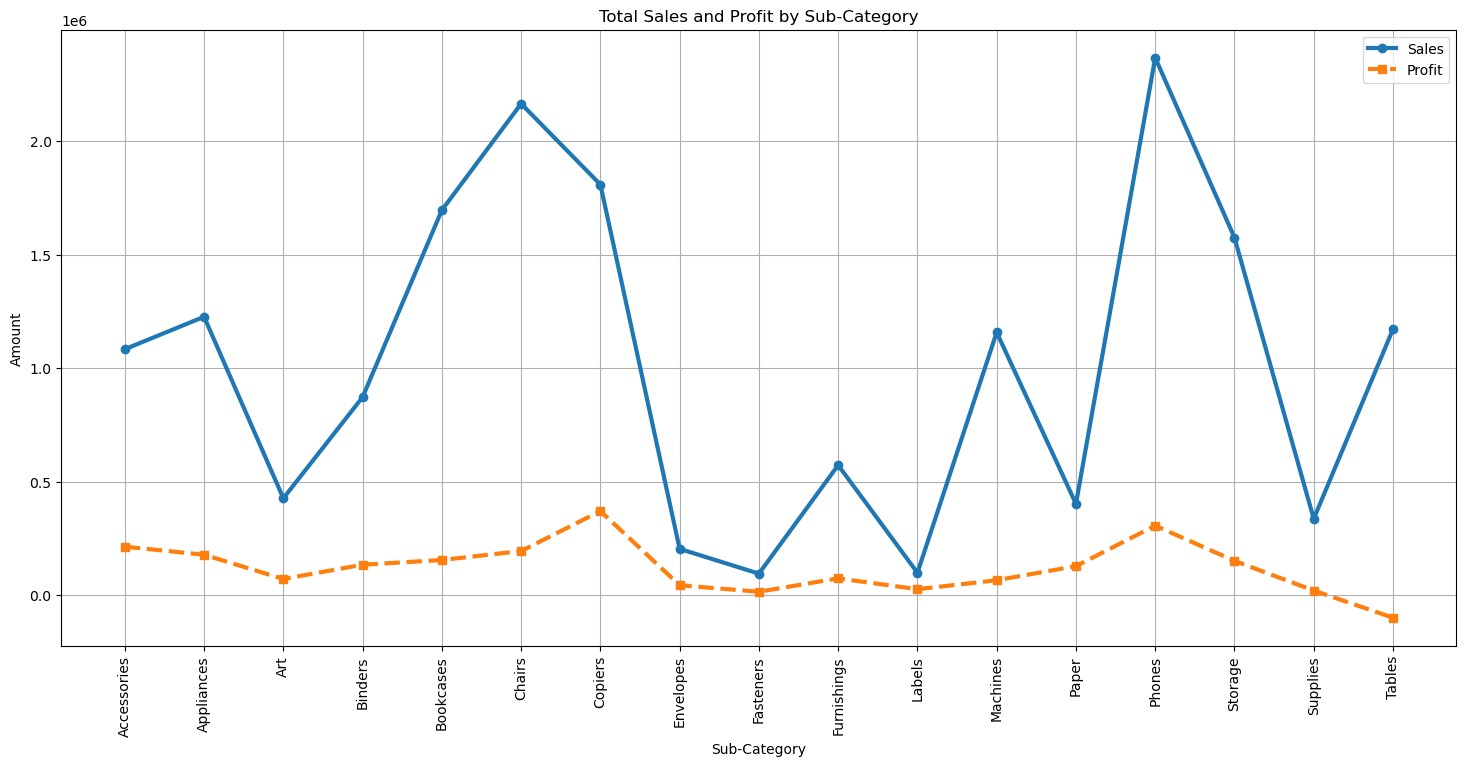

In [6]:
category_sales = df.groupby('Sub-Category')['Sales'].sum()

category_profit = df.groupby('Sub-Category')['Profit'].sum()

plt.figure(figsize=(18,8))

plt.plot(category_sales.index,
         category_sales.values,
         marker='o',
         linewidth=3,
         label='Sales')

plt.plot(category_profit.index,
         category_profit.values,
         marker='s',
         linestyle='--',
         linewidth=3,
         label='Profit')

plt.xticks(rotation=90)

plt.title("Total Sales and Profit by Sub-Category")

plt.xlabel("Sub-Category")

plt.ylabel("Amount")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
print(df.columns)



Index(['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Regional Manager', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Returned', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order'],
      dtype='object')


In [14]:
for col in df.columns:
    print(col)

Row ID
Order ID
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Regional Manager
Product ID
Category
Sub-Category
Product Name
Returned
Sales
Quantity
Discount
Profit
Order


In [16]:
df['Order'] = pd.to_datetime(df['Order'], dayfirst=True)

df['Year'] = df['Order'].dt.year

sales_year = df.groupby(['Year','Sub-Category'])['Sales'].sum().unstack(0)

print(df['Year'].unique())

[2016 2015 2014 2017 2018 2019 2020 2021 2012 2013 2011]


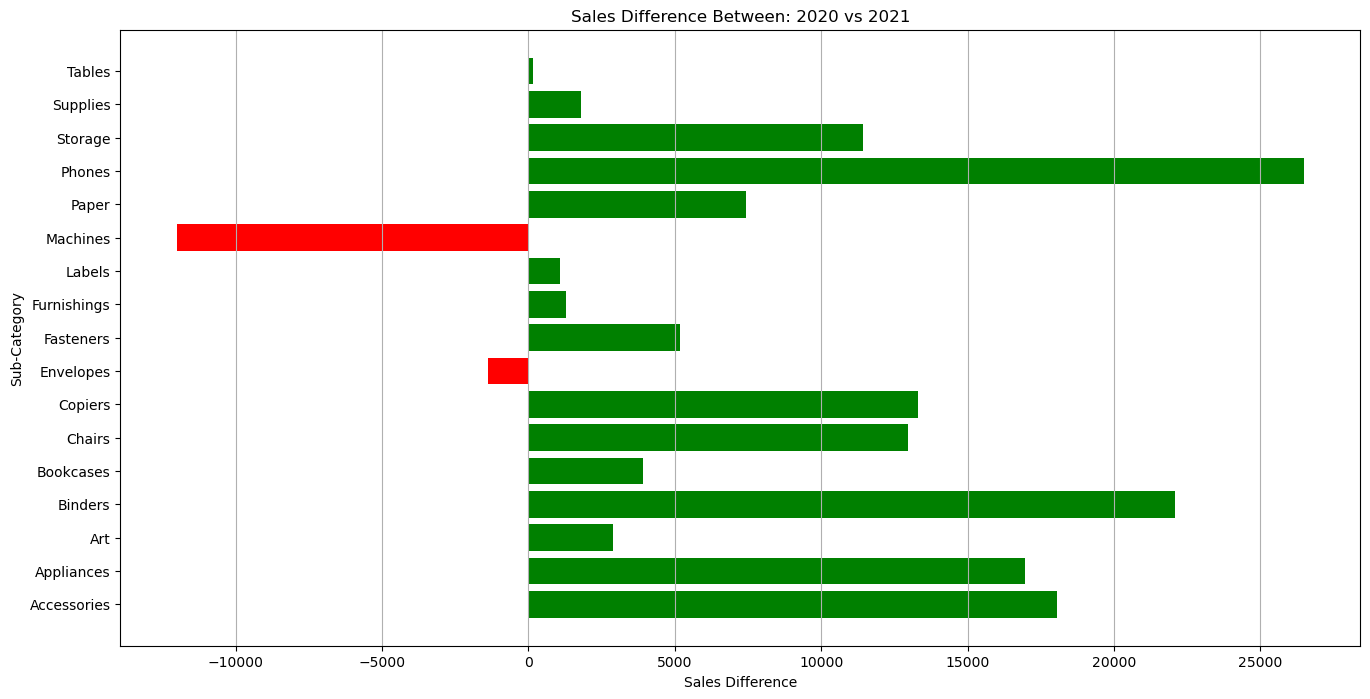

In [17]:
sales_2020 = sales_year[2020]

sales_2021 = sales_year[2021]

difference = sales_2021 - sales_2020

plt.figure(figsize=(16,8))

colors = ['green' if x > 0 else 'red' for x in difference]

plt.barh(difference.index,
         difference.values,
         color=colors)

plt.title("Sales Difference Between: 2020 vs 2021")

plt.xlabel("Sales Difference")

plt.ylabel("Sub-Category")

plt.grid(axis='x')

plt.show()

In [18]:
from sklearn.linear_model import LinearRegression

X = df[['Discount']]

y = df['Sales']

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

Intercept: 266.315536128534
Coefficient: -168.92574707959818


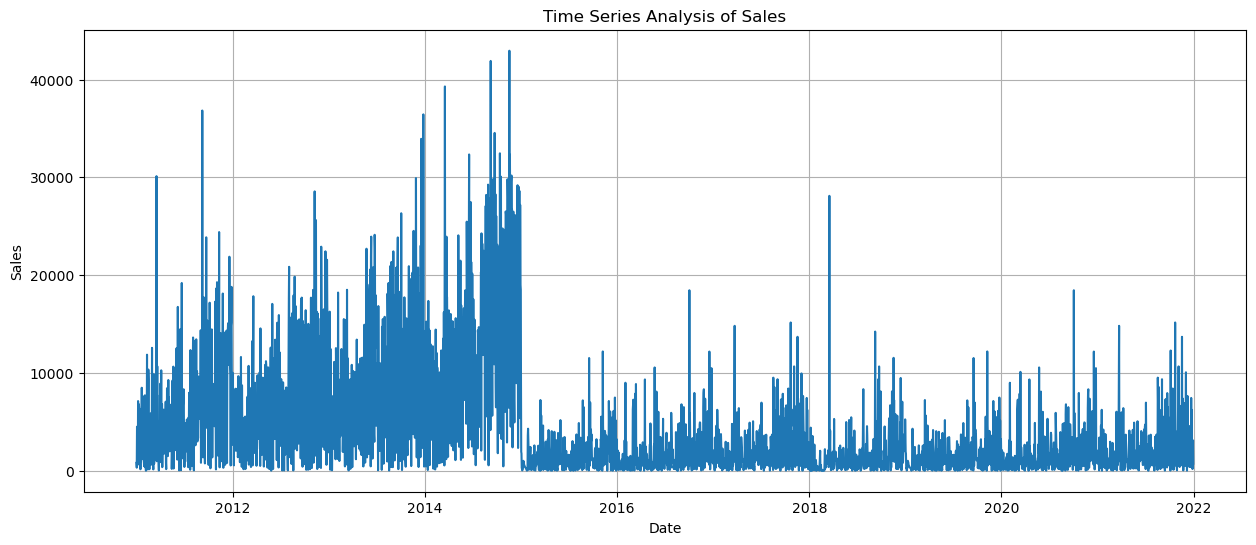

In [25]:
time_sales = df.groupby('Order')['Sales'].sum()

plt.figure(figsize=(15,6))

plt.plot(time_sales)

plt.title("Time Series Analysis of Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
# Linear Regression Analysis

Linear Regression was applied to analyze the relationship between Discount and Sales.

The model shows that discount has an impact on total sales performance.

This helps businesses understand customer buying behavior.

# Time Series Analysis

Time Series Analysis was performed using Order Date and Sales.

The graph shows sales trends over time.

This analysis helps identify seasonal trends and future business growth.

# Conclusion

The project successfully created two visualizations using Python.

Linear Regression and Time Series Analysis provided useful business insights.